load dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ts = pd.read_csv(
    "../data/processed/PGCB_hourly_preprocessed_stage6_continuous.csv",
    parse_dates=["datetime"]
)

print(df_ts.shape)
df_ts.head()

(89101, 61)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,solar_available,india_adani_available,nepal_available,nepal_clean_before_gap_fill,solar_reported,wind_reported,india_adani_reported,nepal_reported,lag_24,row_observed
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,1


EDA dataframe

In [2]:
df_eda = df_ts[
    (df_ts["row_observed"] == 1) &
    (df_ts["demand_mw_clean"].notna())
].copy()

print("EDA observations:", len(df_eda))

EDA observations: 88046


overall demand trend

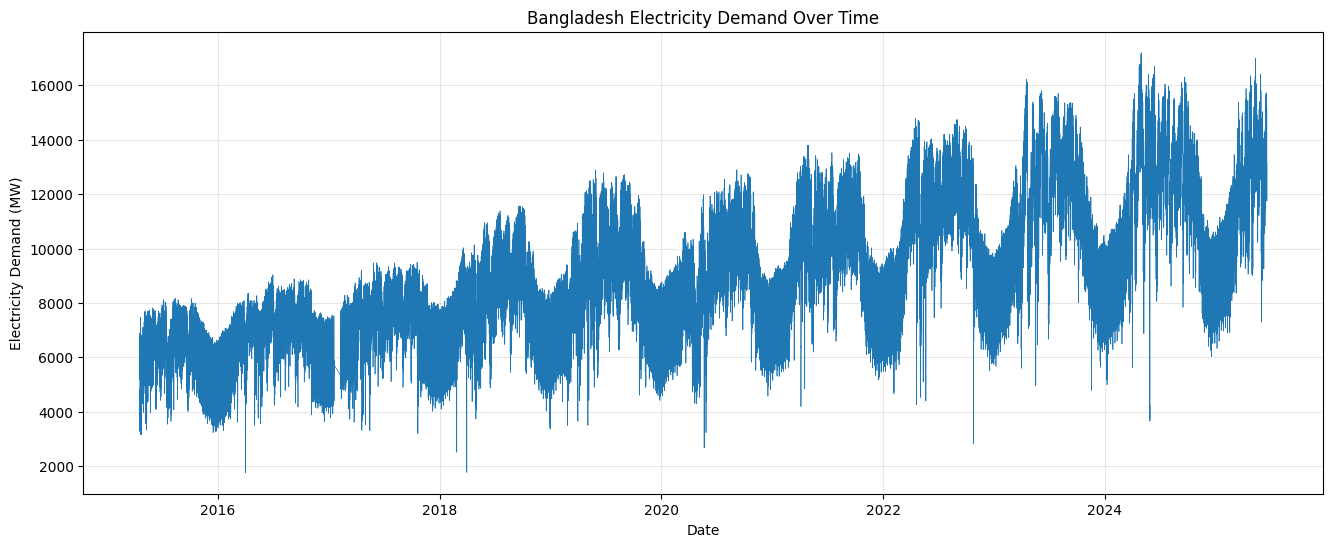

In [3]:
plt.figure(figsize=(16, 6))

plt.plot(
    df_eda["datetime"],
    df_eda["demand_mw_clean"],
    linewidth=0.5
)

plt.title("Bangladesh Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.grid(alpha=0.3)

plt.show()

monthly average trend

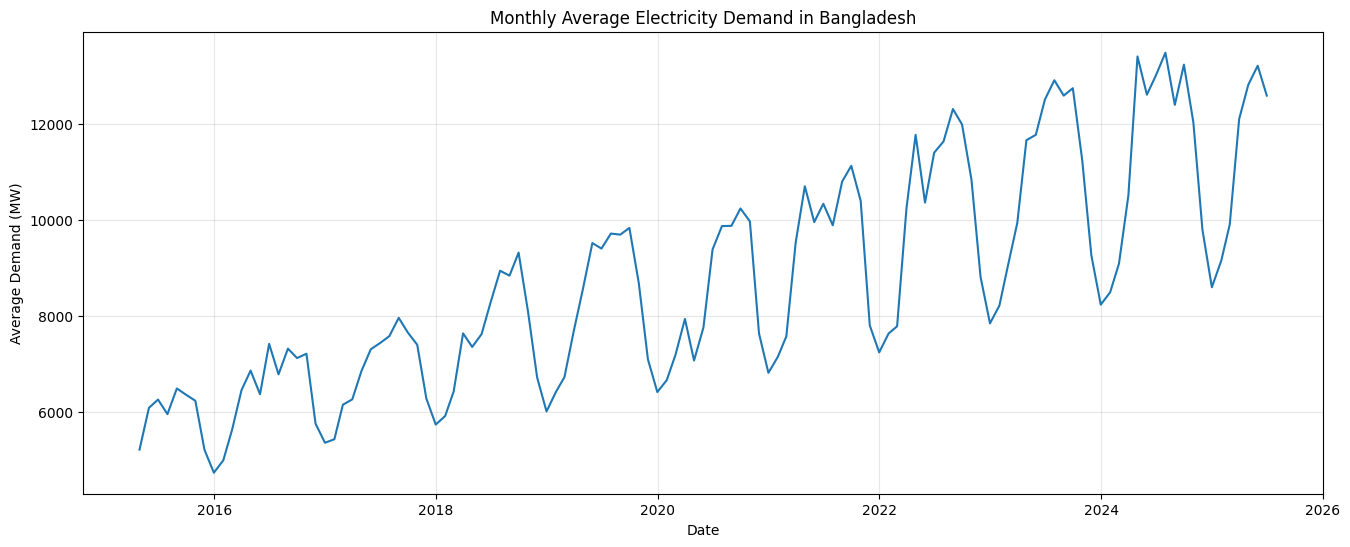

In [4]:
monthly_demand = (
    df_eda
    .set_index("datetime")["demand_mw_clean"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    linewidth=1.5
)

plt.title("Monthly Average Electricity Demand in Bangladesh")
plt.xlabel("Date")
plt.ylabel("Average Demand (MW)")
plt.grid(alpha=0.3)

plt.show()

yearly average demand

In [5]:
df_eda["year"] = df_eda["datetime"].dt.year

yearly_demand = (
    df_eda
    .groupby("year")["demand_mw_clean"]
    .mean()
)

yearly_demand

year
2015     5882.242742
2016     6438.123101
2017     6918.601249
2018     7603.996144
2019     8329.553858
2020     8374.161154
2021     9387.749771
2022    10235.987078
2023    10857.322594
2024    11399.242562
2025    11580.629823
Name: demand_mw_clean, dtype: float64

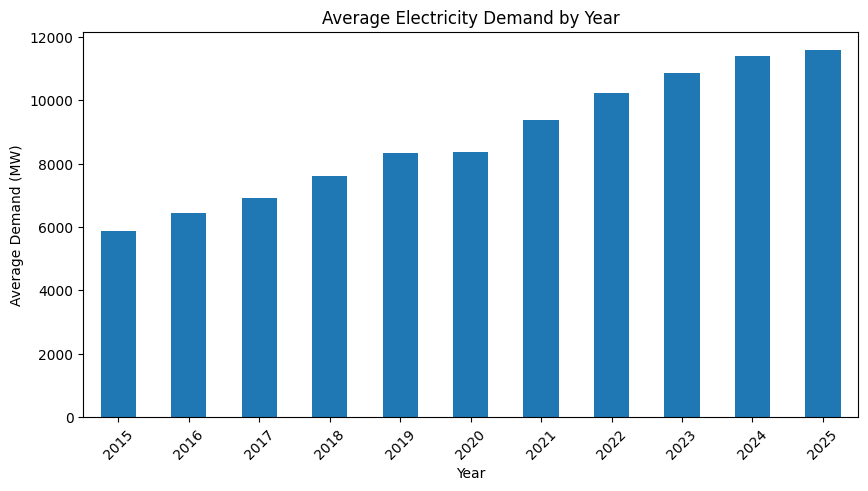

In [6]:
plt.figure(figsize=(10, 5))

yearly_demand.plot(kind="bar")

plt.title("Average Electricity Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average Demand (MW)")
plt.xticks(rotation=45)

plt.show()

### Observation

The yearly average electricity demand shows a clear increasing trend from 2015 to 2025. 
Demand rises from approximately 5,900 MW in 2015 to more than 11,000 MW in recent years. 
The growth is relatively steady, with a smaller increase around 2020, followed by stronger growth from 2021 onward.

This indicates that long-term trend information should be considered in the forecasting models.

Note: The 2025 value represents a partial year because the dataset ends in June 2025.

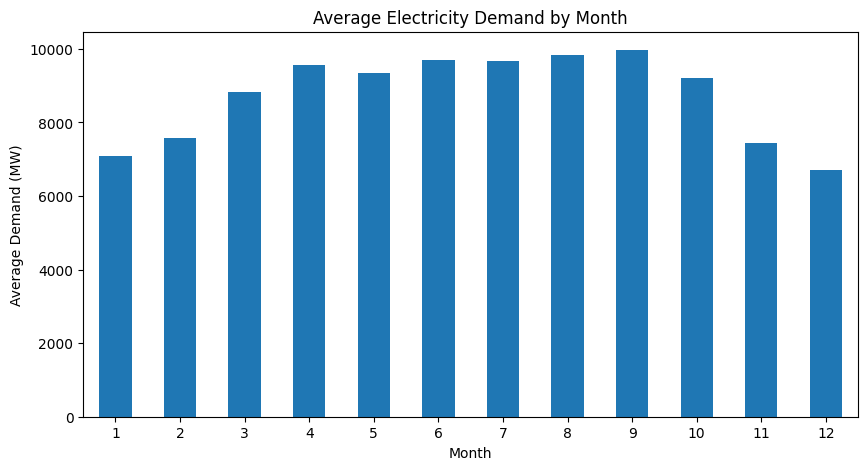

In [7]:
df_eda["month"] = df_eda["datetime"].dt.month

monthly_pattern = (
    df_eda
    .groupby("month")["demand_mw_clean"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_pattern.plot(kind="bar")

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(rotation=0)

plt.show()

### Observation

Electricity demand shows clear monthly seasonality. Demand is relatively low during
December and January, increases from February onward, and remains high from approximately
April to September. The highest average demand occurs around September, after which demand
declines during October, November, and December.

This seasonal pattern suggests that month and seasonal information are important features
for electricity-demand forecasting.

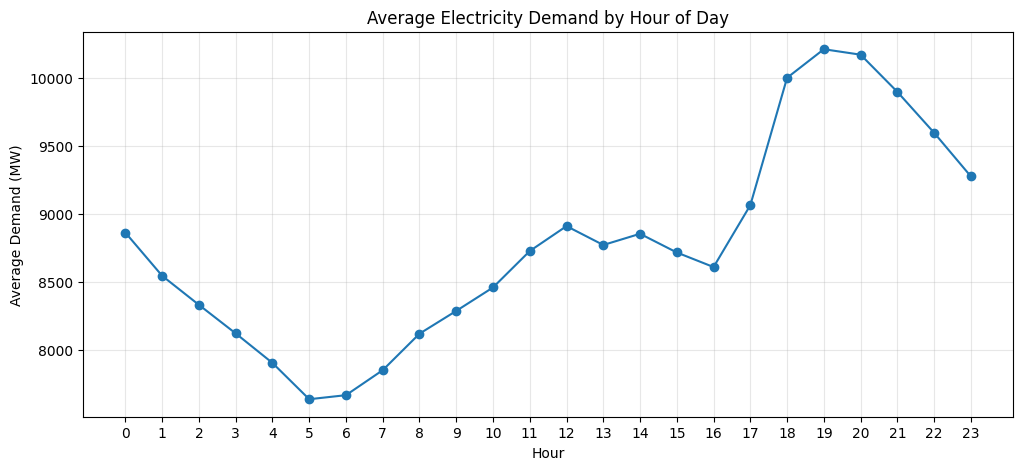

In [8]:
df_eda["hour"] = df_eda["datetime"].dt.hour

hourly_pattern = (
    df_eda
    .groupby("hour")["demand_mw_clean"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Electricity Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.show()

### Observation

Electricity demand exhibits a strong hourly pattern. Demand gradually decreases after
midnight and reaches its lowest level at approximately 05:00. It then increases throughout
the morning and daytime.

A significant increase occurs after 17:00, with the highest average electricity demand
observed around 19:00. Demand remains relatively high during the evening before decreasing
again later at night.

This strong daily periodic pattern indicates that hour-of-day information and historical
demand from the same hour on previous days are likely to be important features for
short-term electricity-demand forecasting.

Day-of-week pattern

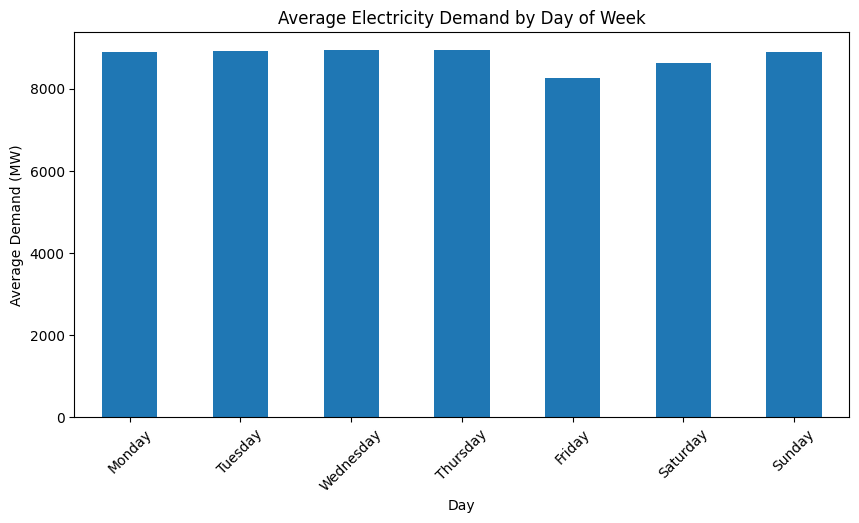

In [9]:
df_eda["day_of_week"] = df_eda["datetime"].dt.dayofweek

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

weekday_pattern = (
    df_eda
    .groupby("day_of_week")["demand_mw_clean"]
    .mean()
)

weekday_pattern.index = [
    day_names[i]
    for i in weekday_pattern.index
]

plt.figure(figsize=(10, 5))

weekday_pattern.plot(kind="bar")

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(rotation=45)

plt.show()

### Observation

Electricity demand varies across the days of the week. Monday through Thursday and Sunday
show relatively similar average demand levels, while Friday has the lowest average demand.
Saturday also shows somewhat lower demand compared with the main working days.

This indicates that day-of-week information is an important feature for electricity-demand
forecasting. In particular, Friday appears to have a distinct demand pattern and should be
represented explicitly in the forecasting models.

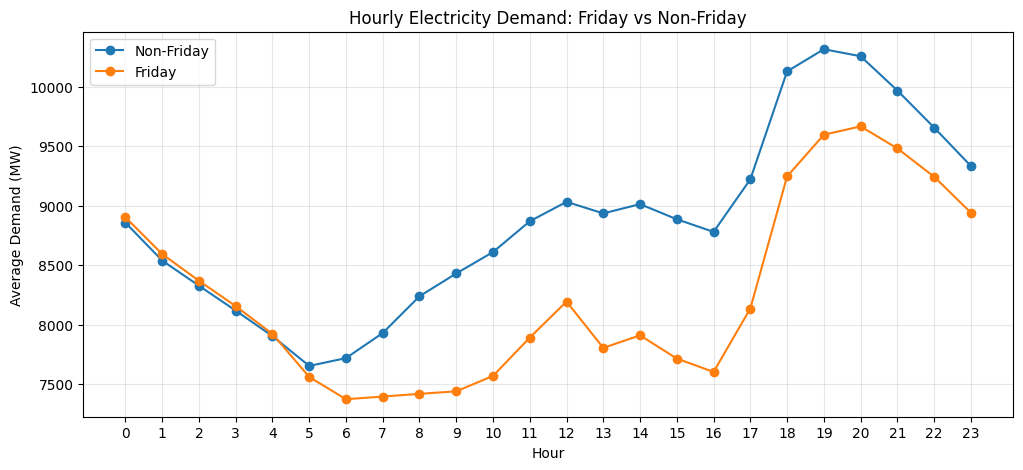

In [10]:
df_eda["is_friday"] = (
    df_eda["datetime"].dt.dayofweek == 4
).astype(int)

friday_hourly = (
    df_eda
    .groupby(["is_friday", "hour"])["demand_mw_clean"]
    .mean()
    .unstack(0)
)

friday_hourly.columns = ["Non-Friday", "Friday"]

plt.figure(figsize=(12, 5))

plt.plot(
    friday_hourly.index,
    friday_hourly["Non-Friday"],
    marker="o",
    label="Non-Friday"
)

plt.plot(
    friday_hourly.index,
    friday_hourly["Friday"],
    marker="o",
    label="Friday"
)

plt.title("Hourly Electricity Demand: Friday vs Non-Friday")
plt.xlabel("Hour")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Observation

Friday exhibits a distinct hourly electricity-demand pattern compared with other days.
During the early morning hours, Friday and non-Friday demand are relatively similar.
However, from approximately 06:00 onward, Friday demand becomes noticeably lower.

Both groups experience an evening peak, but the Friday peak is substantially lower than
the non-Friday peak. This indicates that Friday affects not only average daily demand but
also the magnitude of the intraday demand profile.

Therefore, a dedicated Friday indicator should be considered in the forecasting models
rather than relying only on a general weekend feature.

test the important time lags

In [11]:
lag_values = [
    1,      # previous hour
    2,
    3,
    6,
    12,
    24,     # same hour yesterday
    48,
    72,
    168,    # same hour last week
    336     # same hour two weeks ago
]

lag_correlations = {}

for lag in lag_values:
    lag_correlations[lag] = (
        df_ts["demand_mw_clean"]
        .corr(df_ts["demand_mw_clean"].shift(lag))
    )

lag_correlations

{1: np.float64(0.9848765776295471),
 2: np.float64(0.958015358235029),
 3: np.float64(0.9283880249847085),
 6: np.float64(0.8485452421874042),
 12: np.float64(0.7821662582241872),
 24: np.float64(0.949077572911976),
 48: np.float64(0.9225494433876862),
 72: np.float64(0.9053675520813925),
 168: np.float64(0.8835835582155555),
 336: np.float64(0.8637100102733469)}

In [12]:
lag_corr_df = pd.DataFrame({
    "Lag_Hours": lag_correlations.keys(),
    "Correlation": lag_correlations.values()
})

lag_corr_df

,Lag_Hours,Correlation
0,1,0.984877
1,2,0.958015
2,3,0.928388
3,6,0.848545
4,12,0.782166
5,24,0.949078
6,48,0.922549
7,72,0.905368
8,168,0.883584
9,336,0.863710


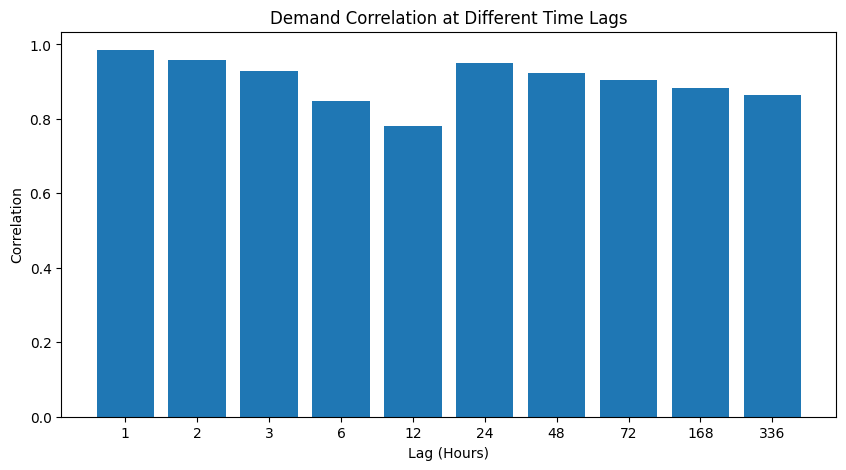

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    lag_corr_df["Lag_Hours"].astype(str),
    lag_corr_df["Correlation"]
)

plt.title("Demand Correlation at Different Time Lags")
plt.xlabel("Lag (Hours)")
plt.ylabel("Correlation")

plt.show()

## EDA Summary

The exploratory analysis revealed several important characteristics of Bangladesh electricity demand:

1. Electricity demand shows a strong long-term increasing trend from 2015 onward.
2. Clear monthly seasonality is present, with higher demand during approximately April–September and lower demand during winter months.
3. Strong intraday seasonality exists, with the lowest demand around early morning and the highest demand around 19:00–20:00.
4. Friday has a distinctly lower demand profile compared with other days, especially during daytime and evening hours.
5. Demand exhibits strong temporal autocorrelation.
6. Very high correlations are observed for recent-hour, 24-hour, and weekly lagged demand values.
7. These findings justify the use of calendar features, lag features, rolling statistics, and periodic temporal components in the forecasting models.

The EDA results will guide both the traditional machine-learning models and the later custom forecasting architectures.